Phol Castañeda Henao - Leonardo Guevara Atehortúa - Grupo 62

Link de github: https://github.com/PholCast/ap-2026-1-62

# Taller ingeniería de datos

El problema que se desea resolver haciendo un modelo predictivo es el siguiente:

*En la industria de telecomunicaciones, la **retención de clientes** es uno de los mayores desafíos para las empresas, ya que la pérdida de clientes (churn) afecta directamente los ingresos y la sostenibilidad del negocio. En este contexto, la empresa que proporciona servicios de telecomunicaciones a través del dataset tiene como objetivo reducir la **tasa de cancelación de sus servicios**. En particular, la variable **Churn Label** identifica a aquellos clientes que han decidido abandonar el servicio. Para abordar este problema, es crucial predecir con antelación qué clientes podrían cancelar su suscripción, para implementar estrategias de retención específicas. Este análisis predictivo no solo ayudaría a identificar a los clientes en riesgo de churn, sino que también podría revelar factores determinantes como la **razón de cancelación**, **tipos de contrato**, **método de pago**, **tasa de uso** y otras variables que influyen en la decisión de los clientes. Por lo tanto, realizar un análisis predictivo basado en estas variables permitirá a la empresa tomar medidas proactivas para mejorar su **estrategia de fidelización** y, en última instancia, reducir el churn y aumentar la **rentabilidad** a largo plazo.*

El equipo de análisis cuenta con un dataset cuyo diccionario de datos se puede consultar en [IBM](https://community.ibm.com/community/user/businessanalytics/blogs/steven-macko/2019/07/11/telco-customer-churn-1113).

## Carga e identificación de problemas de los datos

Abra el archivo de datos en Excel o bloc de notas, y revise sí hay algo particular con los datos. Este paso es importante para evitar problemas posteriores al cargar los datos.

Cargue en `Pandas` el archivo dado, que contiene un dataset cuya información puede consultar en [IBM](https://community.ibm.com/community/user/businessanalytics/blogs/steven-macko/2019/07/11/telco-customer-churn-1113).

Indique cuántas variables y registros tiene el dataset, y asegúrese que el tipo de dato de cada variable sea el esperado.

Reporte las estadísticas descriptivas de las variables numéricas y categóricas.

Identifique si el dataframe tiene datos duplicados.

Identifique si hay variables con datos nulos.

Reporte los hallazgos en un celda de texto.

Hallazgo: 



1. El dataframe tiene 7043 filas y 33 columnas (variables).

2. Las variables son de tipo float64(3), int64(6), object(24)

3. Todas están en su tipo de dato correcto, excepto total_charges que debería ser tipo numérico pero dice tipo object. Para ellos se usó na_values=[' ?', ' '].

4. Las variables con datos nulos son Total Charges y Churn Reason

5. El dataset no contiene datos duplicados

In [331]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "../data/raw/Telco_customer_churn.csv",
    na_values=[' ?', ' ']
)

df

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.40,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.50,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.90,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [332]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

A continuación el reporte de las estadisticas descriptivas:

In [333]:
df.describe()


,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,2283.300441,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,2266.771362,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,18.800000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,401.450000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,1397.475000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,3794.737500,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000


Estadísticas descriptivas de las variables categóricas:

In [334]:
df.describe(include='object')

,CustomerID,Country,State,City,Lat Long,Gender,Senior Citizen,Partner,Dependents,Phone Service,...,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Churn Label,Churn Reason
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043,7043,1869
unique,7043,1,1,1129,1652,2,2,2,2,2,...,3,3,3,3,3,3,2,4,2,20
top,3668-QPYBK,United States,California,Los Angeles,"34.159534, -116.425984",Male,No,No,No,Yes,...,No,No,No,No,No,Month-to-month,Yes,Electronic check,No,Attitude of support person
freq,1,7043,7043,305,5,3555,5901,3641,5416,6361,...,3088,3095,3473,2810,2785,3875,4171,2365,5174,192


In [335]:
# ver proporcion de datos nulos
df.isnull().sum().sort_values(ascending=False)*100/df.shape[0]

Churn Reason         73.463013
Total Charges         0.156183
CustomerID            0.000000
Count                 0.000000
Country               0.000000
Zip Code              0.000000
Lat Long              0.000000
State                 0.000000
City                  0.000000
Gender                0.000000
Senior Citizen        0.000000
Partner               0.000000
Dependents            0.000000
Tenure Months         0.000000
Phone Service         0.000000
Latitude              0.000000
Longitude             0.000000
Internet Service      0.000000
Multiple Lines        0.000000
Online Security       0.000000
Online Backup         0.000000
Streaming TV          0.000000
Streaming Movies      0.000000
Device Protection     0.000000
Tech Support          0.000000
Paperless Billing     0.000000
Contract              0.000000
Monthly Charges       0.000000
Payment Method        0.000000
Churn Label           0.000000
Churn Value           0.000000
Churn Score           0.000000
CLTV    

In [336]:
print('Número de registros duplicados: ', df.duplicated().sum())

Número de registros duplicados:  0


Descarte las variables que considere irrelevantes para su modelo (p.e. claves priamrias, variables con valores únicos, variables redundantes, entre otros).

Gestione los datos duplicados y los datos nulos.

In [337]:
for col in df.select_dtypes(include=["object"]).columns:
    print(f'La columna "{col}" tiene las siguientes categorías: \n {df[col].unique()} \n')

La columna "CustomerID" tiene las siguientes categorías: 
 ['3668-QPYBK' '9237-HQITU' '9305-CDSKC' ... '2234-XADUH' '4801-JZAZL'
 '3186-AJIEK'] 

La columna "Country" tiene las siguientes categorías: 
 ['United States'] 

La columna "State" tiene las siguientes categorías: 
 ['California'] 

La columna "City" tiene las siguientes categorías: 
 ['Los Angeles' 'Beverly Hills' 'Huntington Park' ... 'Standish' 'Tulelake'
 'Olympic Valley'] 

La columna "Lat Long" tiene las siguientes categorías: 
 ['33.964131, -118.272783' '34.059281, -118.30742' '34.048013, -118.293953'
 ... '40.346634, -120.386422' '41.813521, -121.492666'
 '39.191797, -120.212401'] 

La columna "Gender" tiene las siguientes categorías: 
 ['Male' 'Female'] 

La columna "Senior Citizen" tiene las siguientes categorías: 
 ['No' 'Yes'] 

La columna "Partner" tiene las siguientes categorías: 
 ['No' 'Yes'] 

La columna "Dependents" tiene las siguientes categorías: 
 ['No' 'Yes'] 

La columna "Phone Service" tiene las siguien

Se descarta customer id porque es una clave primaria.

Se descarta count, country y state porque son constantes.

Lat long se descarta porque es la combinación de dos variables, entonces es redundante.

Se descarta churn reason porque tiene 73% de datos nulos y porque puede generar data leakage. Pues eso de alguna forma sería hacer trampa porque si tiene churn reason es porque el cliente si abandonó.

Churn label también es redundante.

In [338]:
#Descartando variables

df = df.drop(columns=['CustomerID','Count','Country','State','Lat Long', 'Churn Label','Churn Reason', ])

# se descartan los registros con datos nulos de total charges ya que son pocos (11 registros)
df = df.dropna(subset=['Total Charges'])


In [339]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7032 non-null   object 
 1   Zip Code           7032 non-null   int64  
 2   Latitude           7032 non-null   float64
 3   Longitude          7032 non-null   float64
 4   Gender             7032 non-null   object 
 5   Senior Citizen     7032 non-null   object 
 6   Partner            7032 non-null   object 
 7   Dependents         7032 non-null   object 
 8   Tenure Months      7032 non-null   int64  
 9   Phone Service      7032 non-null   object 
 10  Multiple Lines     7032 non-null   object 
 11  Internet Service   7032 non-null   object 
 12  Online Security    7032 non-null   object 
 13  Online Backup      7032 non-null   object 
 14  Device Protection  7032 non-null   object 
 15  Tech Support       7032 non-null   object 
 16  Streaming TV       7032 non-n

## Análisis de variables categóricas

Haga un análisis de las variables categóricas no descartadas, e identifique:

- Variables nominales.
- Variables ordinales.
- Variables con alta cardinalidad.
- Variables que no deberían incluirse en la matriz de características.

Reporte los resultados del análisis en una celda de texto.

Variables ordinales: La única variable ordinal es Contract ya que sigue un orden de tiempo Month-to-month, One Year y Two Year.

De las variables nominales que quedan después de haber eliminado variables se detecta que city tiene alta cardinalidad con 1129 ciudades.

Las variables categóricas que no deberian incluirse en la matriz de caracteristicas por ser malas predictoras de Churn Value, según los heat maps sería Gender y Phone Service, puesto que no varían mucho o aportan a predecir churn value.



In [340]:
df.describe(include='object').T

,count,unique,top,freq
City,7032,1129,Los Angeles,304
Gender,7032,2,Male,3549
Senior Citizen,7032,2,No,5890
Partner,7032,2,No,3639
Dependents,7032,2,No,5412
Phone Service,7032,2,Yes,6352
Multiple Lines,7032,3,No,3385
Internet Service,7032,3,Fiber optic,3096
Online Security,7032,3,No,3497
Online Backup,7032,3,No,3087


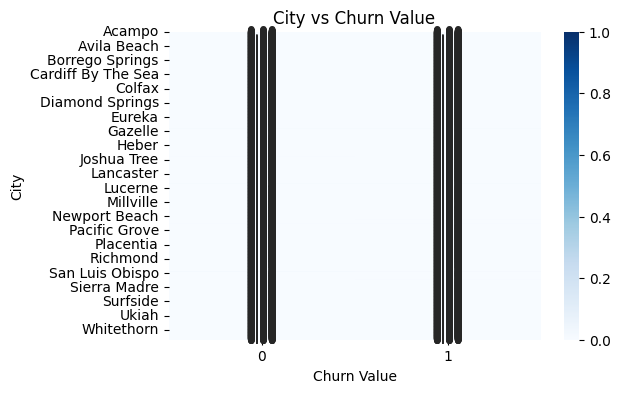

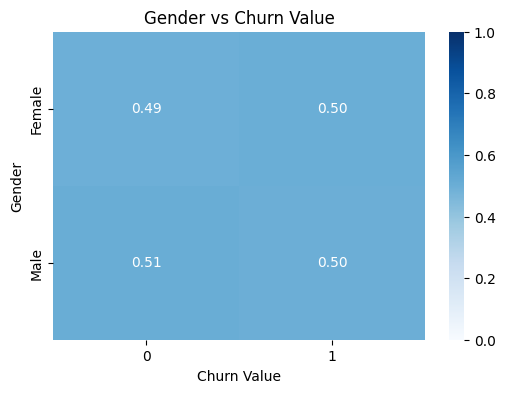

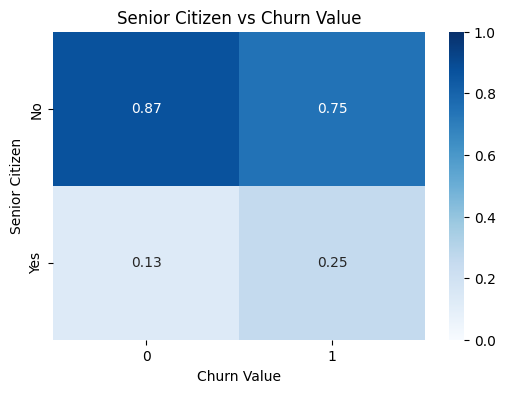

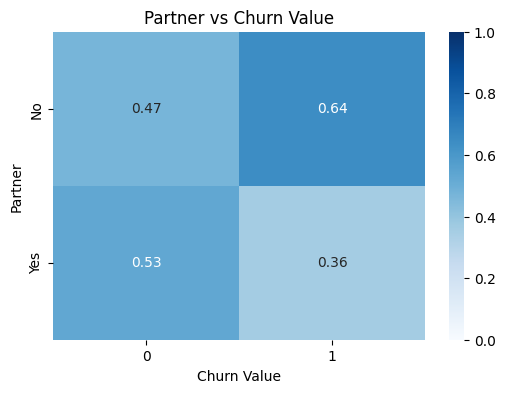

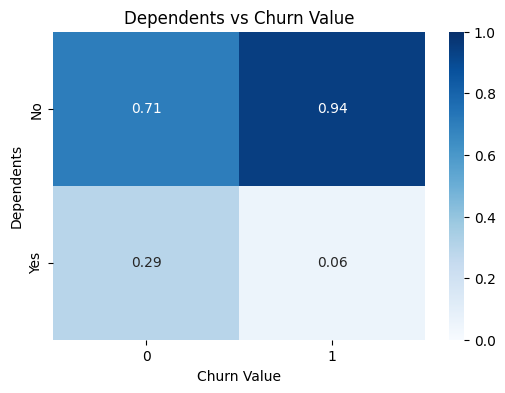

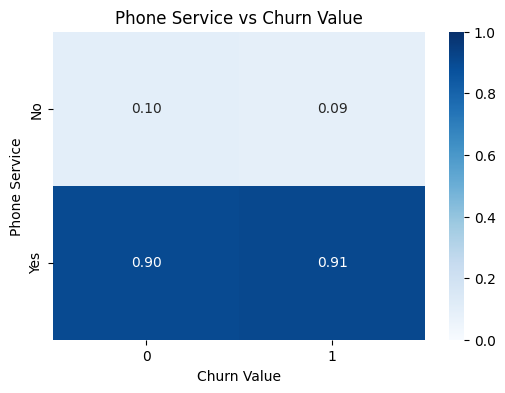

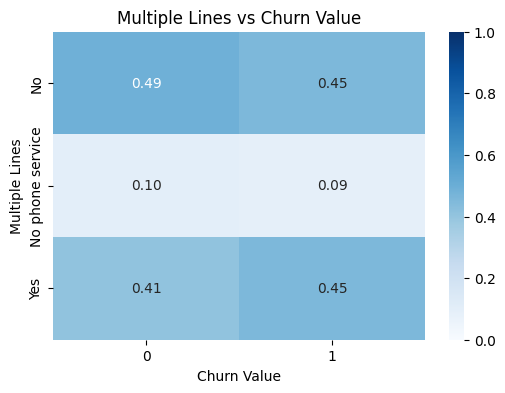

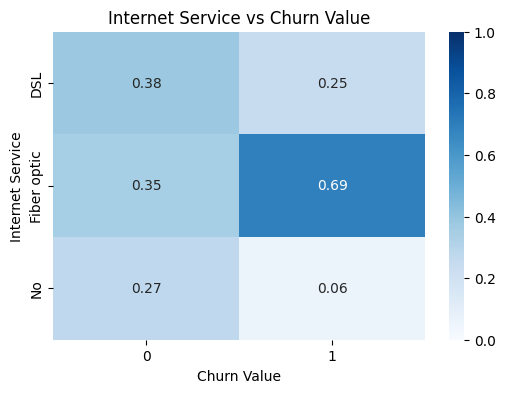

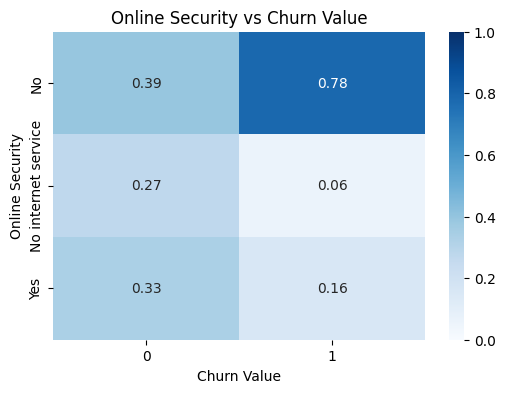

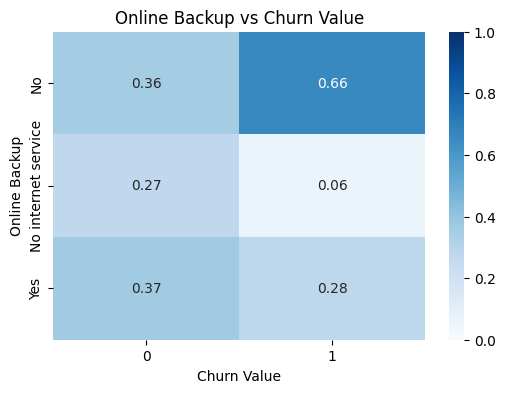

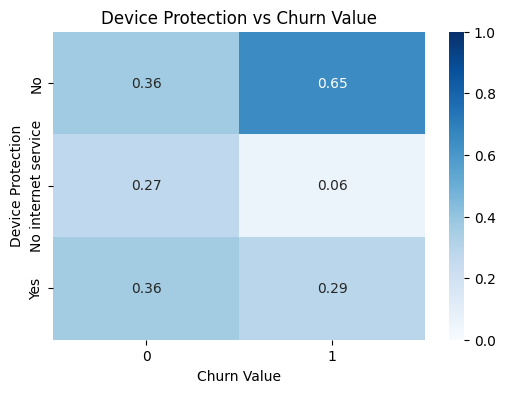

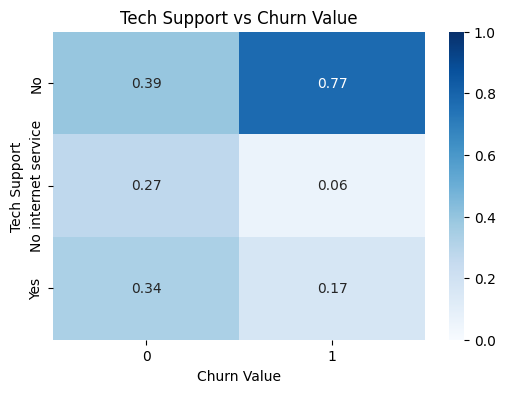

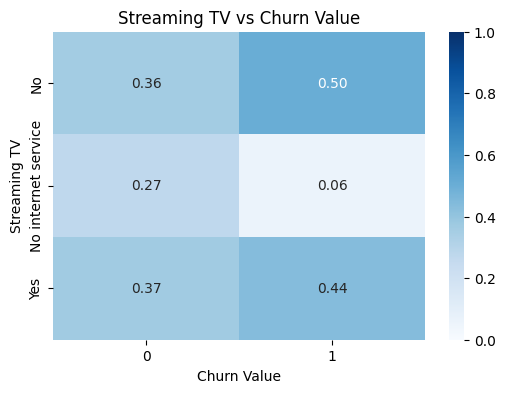

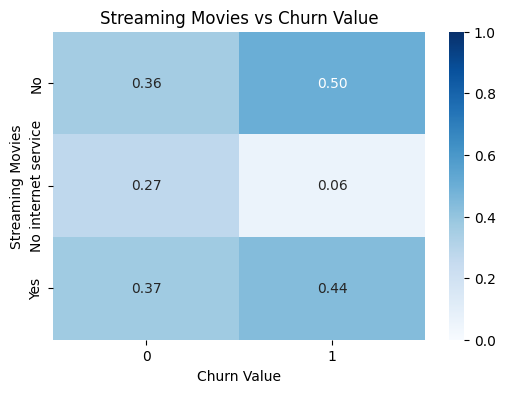

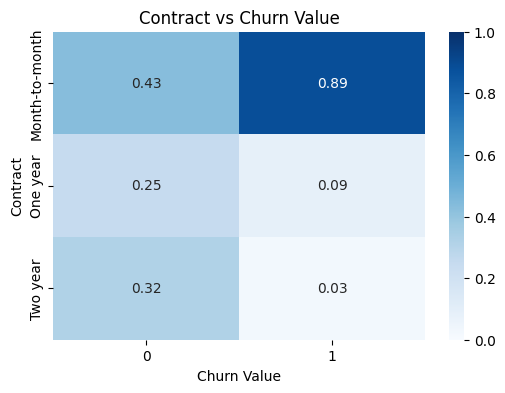

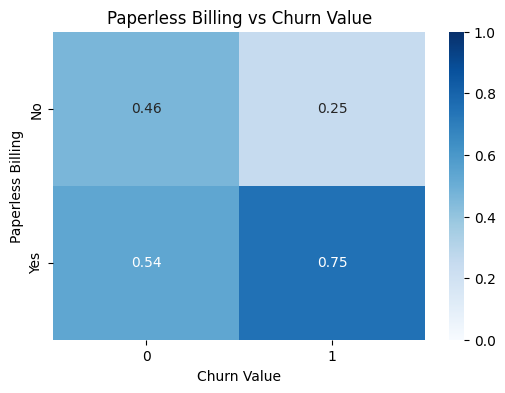

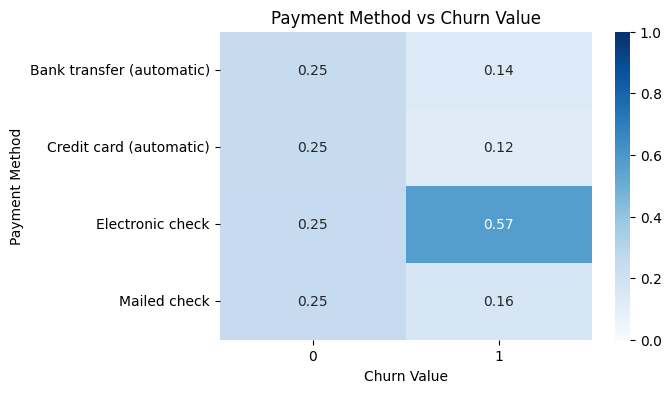

In [341]:
# Variable objetivo
target = "Churn Value"

# Variables cualitativas tipo object
categorical_cols = df.select_dtypes(include=['object']).columns


for col in categorical_cols:
    plt.figure(figsize=(6,4))
    
    tabla = pd.crosstab(df[col], df[target], normalize='columns')
    
    sns.heatmap(tabla, 
                annot=True, 
                fmt='.2f', 
                vmin=0, vmax=1,
                cmap="Blues")
    
    plt.title(f"{col} vs {target}")
    plt.ylabel(col)
    plt.xlabel(target)
    plt.show()

In [342]:
df = df.drop(columns=['Gender','Phone Service'])

df

,City,Zip Code,Latitude,Longitude,Senior Citizen,Partner,Dependents,Tenure Months,Multiple Lines,Internet Service,...,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
0,Los Angeles,90003,33.964131,-118.272783,No,No,No,2,No,DSL,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,86,3239
1,Los Angeles,90005,34.059281,-118.307420,No,No,Yes,2,No,Fiber optic,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,67,2701
2,Los Angeles,90006,34.048013,-118.293953,No,No,Yes,8,Yes,Fiber optic,...,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,86,5372
3,Los Angeles,90010,34.062125,-118.315709,No,Yes,Yes,28,Yes,Fiber optic,...,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,84,5003
4,Los Angeles,90015,34.039224,-118.266293,No,No,Yes,49,Yes,Fiber optic,...,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,89,5340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Landers,92285,34.341737,-116.539416,No,No,No,72,No,No,...,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.40,0,45,5306
7039,Adelanto,92301,34.667815,-117.536183,No,Yes,Yes,24,Yes,DSL,...,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0,59,2140
7040,Amboy,92304,34.559882,-115.637164,No,Yes,Yes,72,Yes,Fiber optic,...,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0,71,5560
7041,Angelus Oaks,92305,34.167800,-116.864330,No,Yes,Yes,11,No phone service,DSL,...,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0,59,2793


## Análisis de variables cuantitativas

Haga un análisis de las variables cuantitativas no descartadas, e identifique:

- Variables que son aproximadamente normales.
- Variables con datos atípicos.
- Variables que no deberían incluirse en la matriz de características.

Reporte los resultados del análisis en una celda de texto.

1. No se encuentra que ninguna variable cumpla estrictamente con el supuesto de normalidad, pues se encuentran diferentes tipo de asimetría, positiva y negativa. 
Aunque algunas presentan valores de asimetría cercanos a cero, sus distribuciones no son unimodales ni presentan forma de campana.

2. No se encuentran outliers en la siguiente gráfica de boxplot, pues no hay puntos por fuera de los bigotes.

3. Zip Code, Latitude y Longitude: No existe ninguna diferencia visual en el boxplot en la distribución de estas variables entre quienes se quedan y quienes se van. Esto de alguna forma nos dice que la ubicación geográfica no influye, entonces no se incluirá en la matriz de carecterísticas

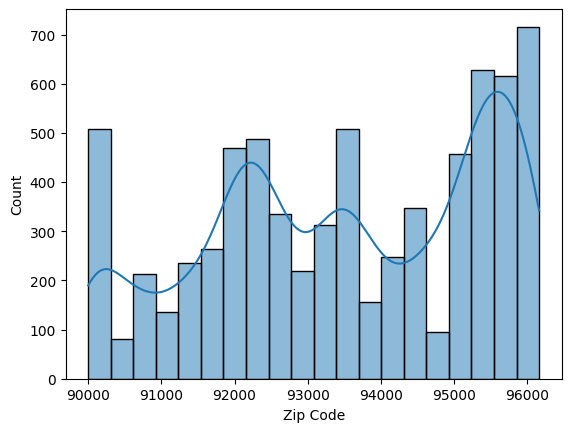

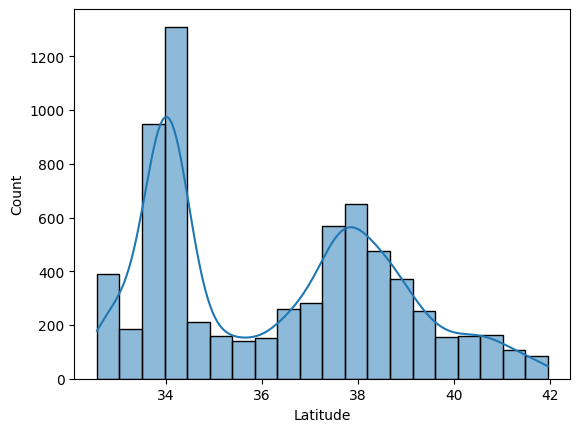

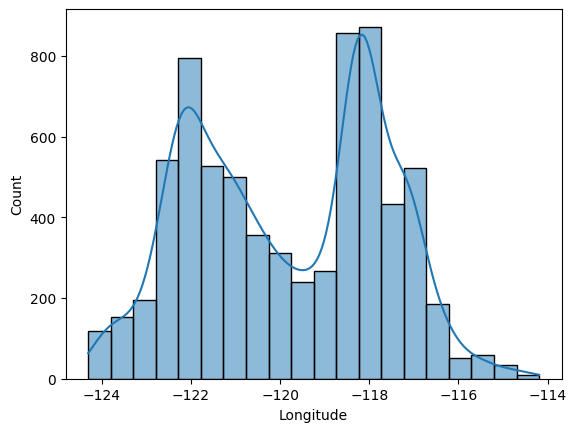

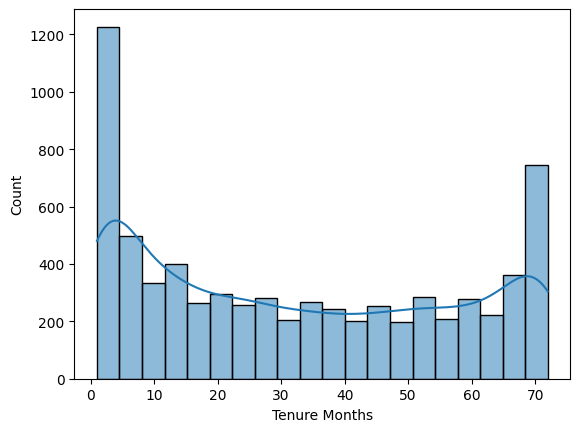

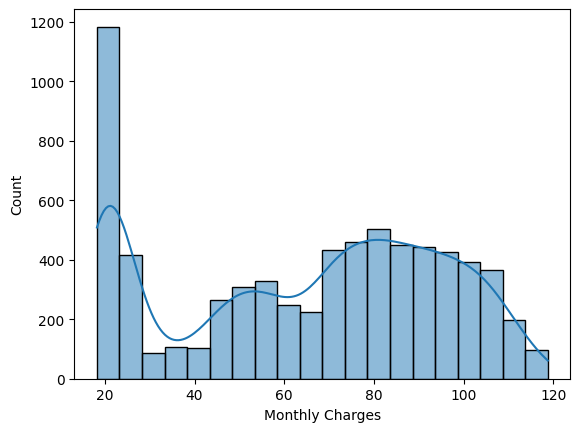

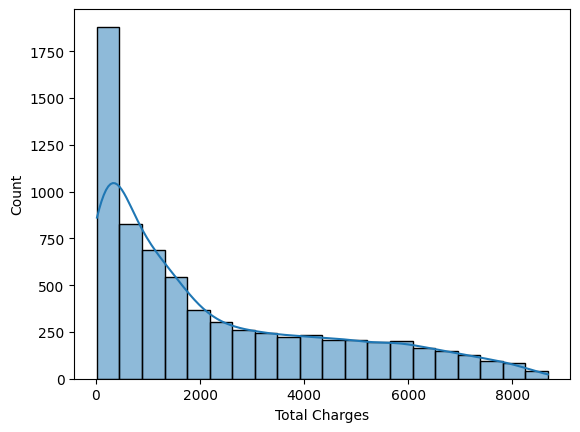

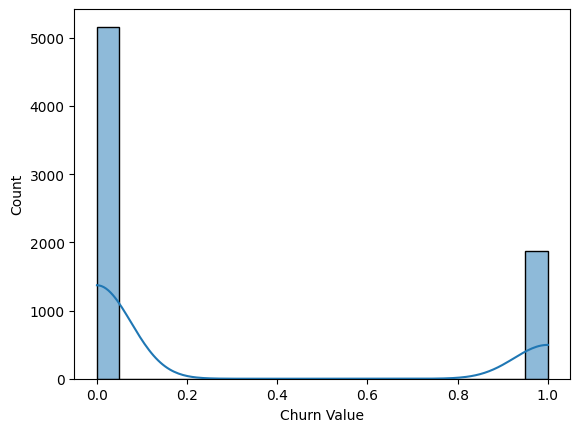

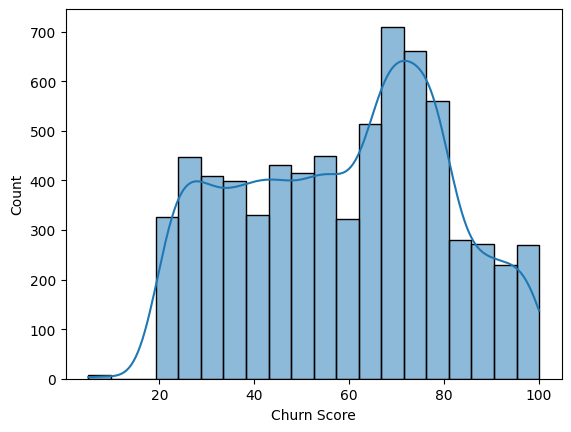

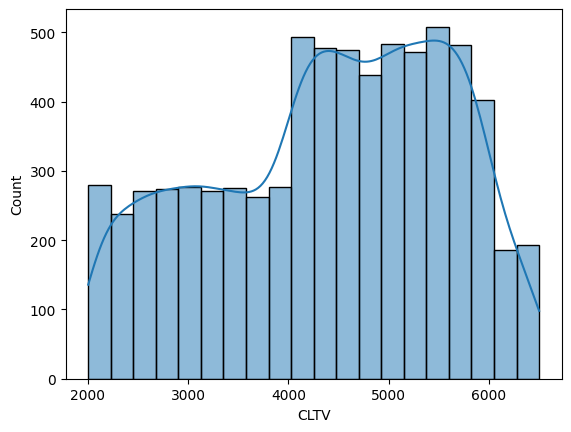

In [343]:
for col in df.select_dtypes(include=['number']).columns:
    plt.figure()
    sns.histplot(data=df, x=col, bins=20, kde=True)
    plt.show();

In [344]:
for num in df.select_dtypes(include=['number']).columns:
    print(f"Asimetría de {num}: {df[num].skew():.3f} \n")

Asimetría de Zip Code: -0.252 

Asimetría de Latitude: 0.303 

Asimetría de Longitude: -0.040 

Asimetría de Tenure Months: 0.238 

Asimetría de Monthly Charges: -0.222 

Asimetría de Total Charges: 0.962 

Asimetría de Churn Value: 1.061 

Asimetría de Churn Score: -0.091 

Asimetría de CLTV: -0.311 



In [345]:
for num in df.select_dtypes(include=['number']).columns:
    print(f"Kurtosis de {num}: {df[num].kurt():.3f} \n")

Kurtosis de Zip Code: -1.154 

Kurtosis de Latitude: -1.136 

Kurtosis de Longitude: -1.135 

Kurtosis de Tenure Months: -1.388 

Kurtosis de Monthly Charges: -1.256 

Kurtosis de Total Charges: -0.232 

Kurtosis de Churn Value: -0.875 

Kurtosis de Churn Score: -1.006 

Kurtosis de CLTV: -0.933 



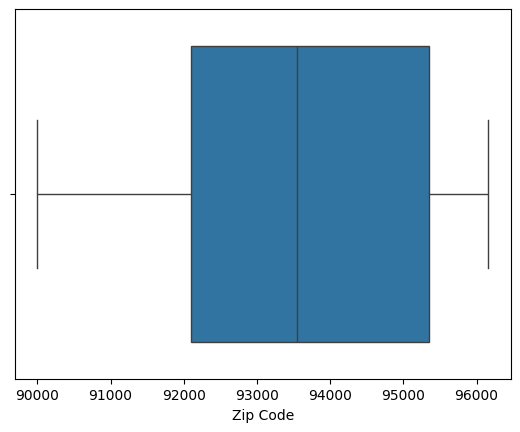

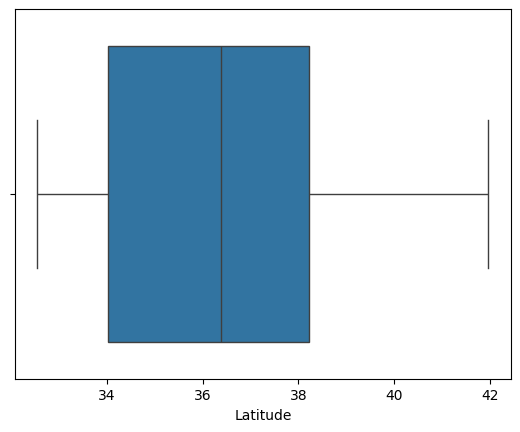

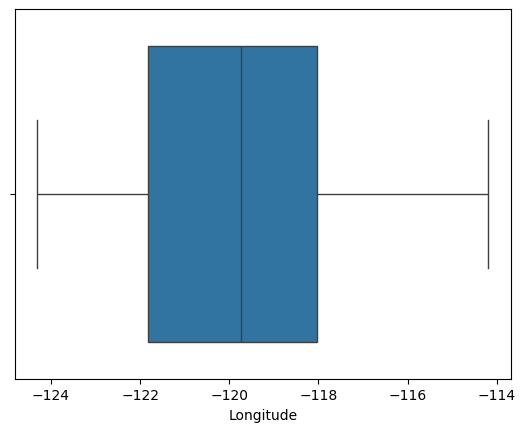

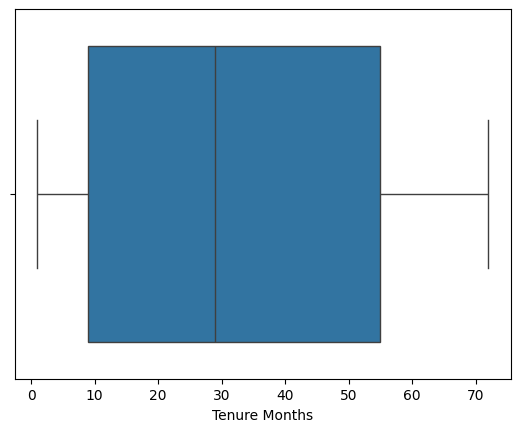

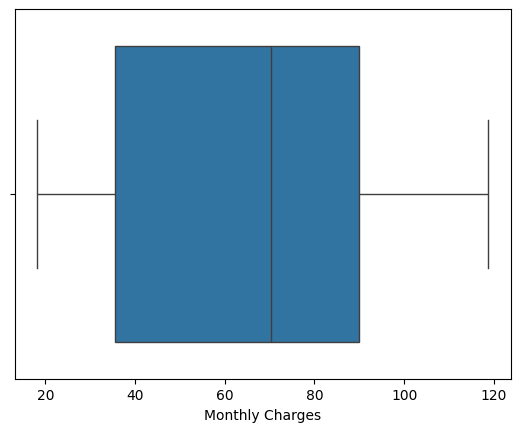

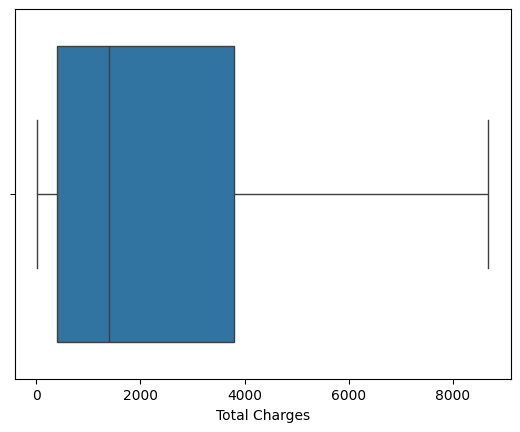

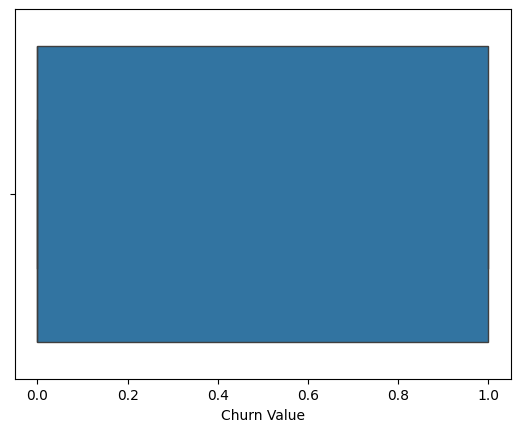

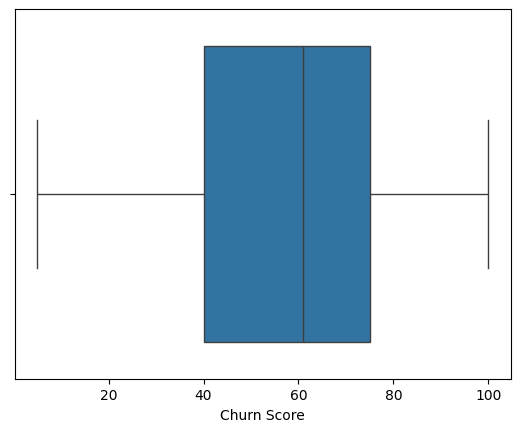

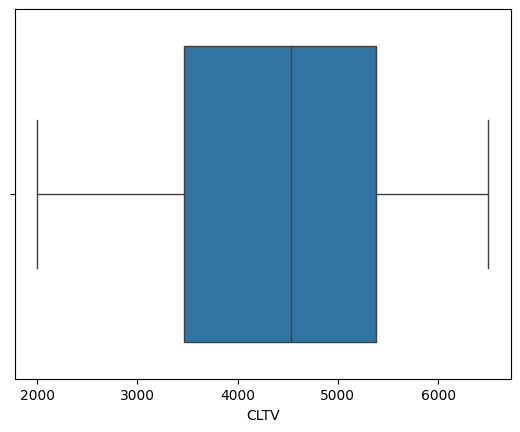

In [346]:
for num in df.select_dtypes(include=['number']).columns:
    plt.figure()
    sns.boxplot(data=df, x=num)
    plt.show();

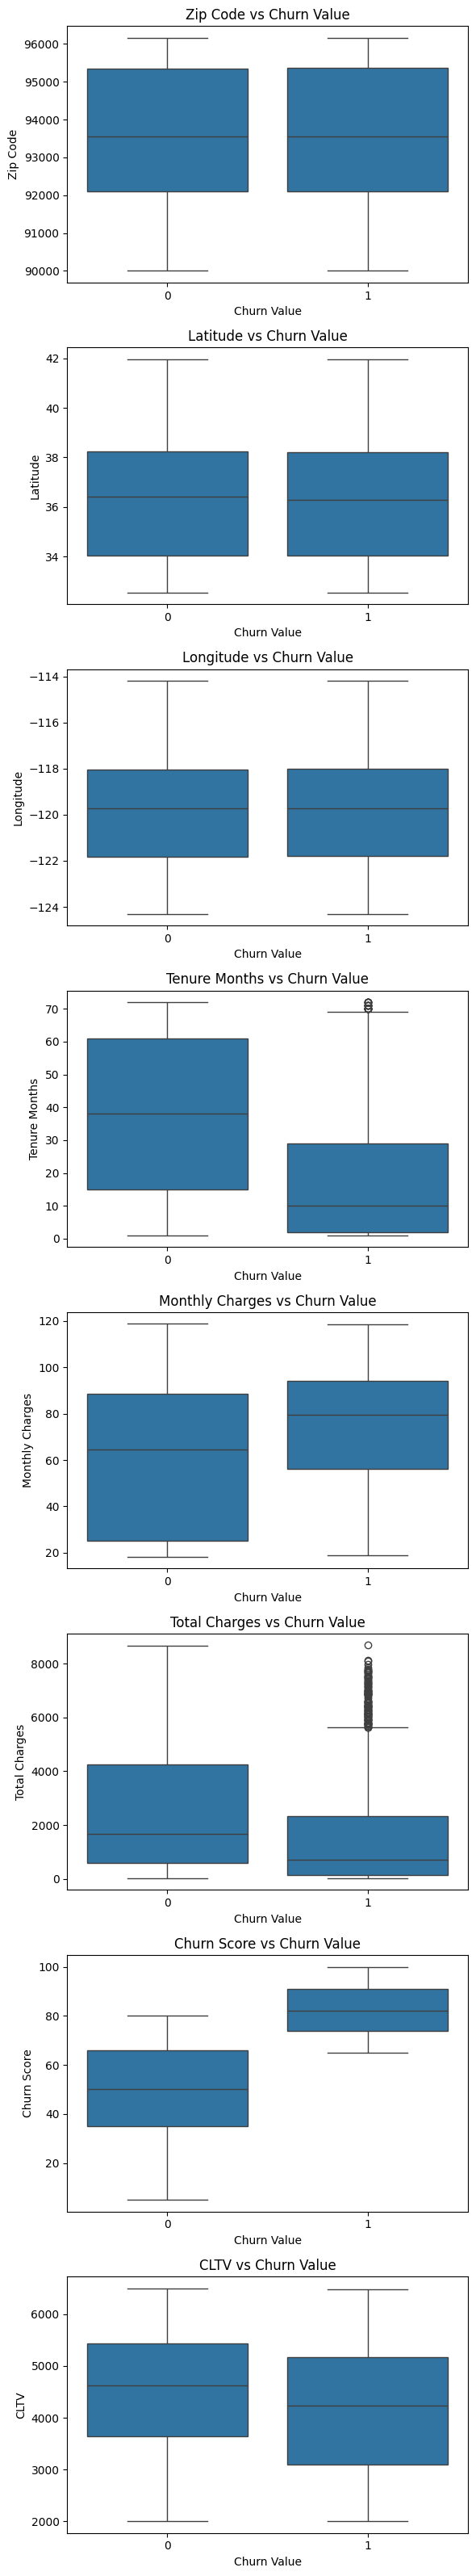

In [347]:
# Variable cualitativa
categorical_var = "Churn Value"

# Variables cuantitativas (excluyendo la binaria)
numeric_cols = df.select_dtypes(include=['number']).columns
numeric_cols = [col for col in numeric_cols if col != categorical_var]

plt.figure(figsize=(6, 4*len(numeric_cols)))  # una sola figura grande

for i, col in enumerate(numeric_cols):
    plt.subplot(len(numeric_cols), 1, i+1)  # varios gráficos en la misma imagen
    sns.boxplot(data=df, x=categorical_var, y=col)
    plt.title(f"{col} vs {categorical_var}")

plt.tight_layout()
plt.show()

In [348]:
df = df.drop(columns=['Zip Code','Latitude','Longitude'])
df

,City,Senior Citizen,Partner,Dependents,Tenure Months,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,...,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
0,Los Angeles,No,No,No,2,No,DSL,Yes,Yes,No,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,86,3239
1,Los Angeles,No,No,Yes,2,No,Fiber optic,No,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,67,2701
2,Los Angeles,No,No,Yes,8,Yes,Fiber optic,No,No,Yes,...,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,86,5372
3,Los Angeles,No,Yes,Yes,28,Yes,Fiber optic,No,No,Yes,...,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,84,5003
4,Los Angeles,No,No,Yes,49,Yes,Fiber optic,No,Yes,Yes,...,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,89,5340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Landers,No,No,No,72,No,No,No internet service,No internet service,No internet service,...,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.40,0,45,5306
7039,Adelanto,No,Yes,Yes,24,Yes,DSL,Yes,No,Yes,...,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0,59,2140
7040,Amboy,No,Yes,Yes,72,Yes,Fiber optic,No,Yes,Yes,...,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0,71,5560
7041,Angelus Oaks,No,Yes,Yes,11,No phone service,DSL,Yes,No,No,...,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0,59,2793


## Entrenamiento del modelo

Entrene un modelo de árbol de decisión que prediga la variable **Churn Value**.

Procese las variables de acuerdo con los análisis de variables cuantitativas y categóricas hechos previamente. Este procesamiento debe empaquetarse usando `ColumnTransformer`, para que los datos de entrenamiento y prueba sean procesados por separado.

Reporte los `scores` de entrenamiento y prueba.

Reporte las características con las que **realmente** fue entrenado el modelo, es decir, las resultantes del preprocesamiento.

In [349]:
from sklearn.model_selection import train_test_split

X = df.drop(['Churn Value'], axis=1)
y = df['Churn Value']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, train_size=0.7)
print(f'Tamaño del conjunto de entrenamiento es: {X_train.shape}')
print(f'Tamaño del conjunto de prueba es: {X_test.shape}')

Tamaño del conjunto de entrenamiento es: (4922, 20)
Tamaño del conjunto de prueba es: (2110, 20)


In [350]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, PowerTransformer
from sklearn.compose import ColumnTransformer

ss = StandardScaler() 
pt = PowerTransformer() 
orden = ['Month-to-month', 'One year', 'Two year']
ore = OrdinalEncoder(categories=[orden], dtype='int') 
ohe = OneHotEncoder(sparse_output=False, drop='if_binary') 


oheCardinalidad = OneHotEncoder(
    sparse_output=False,
    max_categories=6,
    handle_unknown='ignore' 
    )

In [351]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7032 non-null   object 
 1   Senior Citizen     7032 non-null   object 
 2   Partner            7032 non-null   object 
 3   Dependents         7032 non-null   object 
 4   Tenure Months      7032 non-null   int64  
 5   Multiple Lines     7032 non-null   object 
 6   Internet Service   7032 non-null   object 
 7   Online Security    7032 non-null   object 
 8   Online Backup      7032 non-null   object 
 9   Device Protection  7032 non-null   object 
 10  Tech Support       7032 non-null   object 
 11  Streaming TV       7032 non-null   object 
 12  Streaming Movies   7032 non-null   object 
 13  Contract           7032 non-null   object 
 14  Paperless Billing  7032 non-null   object 
 15  Payment Method     7032 non-null   object 
 16  Monthly Charges    7032 non-n

In [352]:
from sklearn.compose import ColumnTransformer

cat_columns = [
    'Senior Citizen',
    'Partner',
    'Dependents',
    'Multiple Lines',
    'Internet Service',
    'Online Security',
    'Online Backup',
    'Device Protection',
    'Tech Support',
    'Streaming TV',
    'Streaming Movies',
    'Paperless Billing',
    'Payment Method'
]


preprocessor = ColumnTransformer(transformers=[

    ('num_prep_pt', pt, ['Tenure Months', 'Monthly Charges', 'Total Charges']),

    ('num_scaler', ss, ['Churn Score', 'CLTV']),

    ('contract_ord', ore, ['Contract']),

    ('cat_oh', ohe, cat_columns),

    ('cat_cardinal', oheCardinalidad, ['City'])

], remainder='drop')

In [353]:
preprocessor

,transformers,"[('num_prep_pt', ...), ('num_scaler', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,method,'yeo-johnson'
,standardize,True
,copy,True


In [354]:
preprocessor.fit(X_train)
X_train_prep = preprocessor.transform(X_train)
X_test_prep = preprocessor.transform(X_test)

In [355]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=1
    )

tree.fit(X_train_prep, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Scores de entrenamiento y prueba:

In [356]:
print(f'Accuracy en el conjunto de entrenamiento: {tree.score(X_train_prep, y_train)}')
print(f'Accuracy en el conjunto de prueba: {tree.score(X_test_prep, y_test)}')

Accuracy en el conjunto de entrenamiento: 0.9250304754164974
Accuracy en el conjunto de prueba: 0.9303317535545024


In [357]:
print(preprocessor.get_feature_names_out())

['num_prep_pt__Tenure Months' 'num_prep_pt__Monthly Charges'
 'num_prep_pt__Total Charges' 'num_scaler__Churn Score' 'num_scaler__CLTV'
 'contract_ord__Contract' 'cat_oh__Senior Citizen_Yes'
 'cat_oh__Partner_Yes' 'cat_oh__Dependents_Yes'
 'cat_oh__Multiple Lines_No' 'cat_oh__Multiple Lines_No phone service'
 'cat_oh__Multiple Lines_Yes' 'cat_oh__Internet Service_DSL'
 'cat_oh__Internet Service_Fiber optic' 'cat_oh__Internet Service_No'
 'cat_oh__Online Security_No'
 'cat_oh__Online Security_No internet service'
 'cat_oh__Online Security_Yes' 'cat_oh__Online Backup_No'
 'cat_oh__Online Backup_No internet service' 'cat_oh__Online Backup_Yes'
 'cat_oh__Device Protection_No'
 'cat_oh__Device Protection_No internet service'
 'cat_oh__Device Protection_Yes' 'cat_oh__Tech Support_No'
 'cat_oh__Tech Support_No internet service' 'cat_oh__Tech Support_Yes'
 'cat_oh__Streaming TV_No' 'cat_oh__Streaming TV_No internet service'
 'cat_oh__Streaming TV_Yes' 'cat_oh__Streaming Movies_No'
 'cat_oh__St

In [358]:
print('El número de características con las que fue realmente entrenado el modelo son: ', preprocessor.get_feature_names_out().shape[0])

El número de características con las que fue realmente entrenado el modelo son:  44
